# Optimus Prime: Dynamic restructuring of uncertain calibration dependencies

The existing Optimus algorithm treats calibration routines as nodes in a directed dependency graph.
This notebook uses a small simulation to illustrate a possible method for automatically refining the structure of these graphs over time. By aligning the selection of dependencies with the learned likelihood that a given miscalibration actually causes some other miscalibration, we can minimize
- false positives where time is spent collecting data to resolve miscalibrations that didn't occur in the first place
- false negatives that cause an unnecessary delay between the point at which a node becomes miscalibrated and when it's brought back into spec (which ultimately leads to more avoidable data collection, in order to resolve dependent miscalibrations that occur during this delay)

**Edge convention:** `u -> v` means calibration routine `u` depends on calibration routine `v`.


In [1]:
from pathlib import Path
import json
import sys

import numpy as np
from IPython.display import Image, display

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "simulate_dependency_learning.py").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT))

from simulate_dependency_learning import (
    SimulationConfig,
    config_for_json,
    cost_curve,
    create_prior_weights,
    edge_recall_metrics,
    generate_hidden_true_dag,
    graph_from_scores,
    mean_recalibration_cost,
    plot_cost_curve,
    plot_pr_curves,
    plot_proposal_summary_figure,
    plot_weight_heatmaps,
    select_operating_threshold,
    simulate_check_data_observations,
    simulate_hidden_event,
    threshold_tradeoff_curve,
    update_weights_from_observations,
)

OUTPUT_DIR = PROJECT_ROOT / "outputs"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

config = SimulationConfig(output_dir=OUTPUT_DIR)
rng = np.random.default_rng(config.seed)
config

SimulationConfig(n_nodes=30, n_events=600, seed=7, p_true=0.08, obs_noise=0.05, output_dir=PosixPath('/Users/rtbyrne/Documents/job_apps/job_apps/optimus_prime/outputs'), spatial_locality=True, locality_scale=0.35, propagation_prob=0.8, known_true_fraction=0.55, known_false_positive_fraction=0.05, affected_observation_prob=0.95, background_observation_prob=0.25, diagnose_success_prob=0.75, eta_pos=0.65, eta_neg=0.35, eta_neg_mild=0.08, eta_coaffected=0.03)

## Toy model

Given the assumption that it's unclear a priori whether certain dependency edges should exist, we can start with a dense prior that includes all of those edges (along with the ones that we do know are necessary), assigning edge weights in the interval [0, 1] to represent how certain we currently are that any given dependency is physically justified. We can then update these edge weights dynamically as more calibration data is collected.

Here is a brief example of an observed structural inconsistency where this edge update would occur, given a chain of dependencies `E -> D -> C -> B -> A`:
1. Suppose `diagnose` is called on `E`, and `D` is found to have bad data and subsequently brought back into spec.
2. During this, `diagnose` determines that `C` is already in-spec.
3. If we override the typical `diagnose` traversal rule, we can proceed by checking if `B` has bad data, in which case the dependency edge `C -> B` should have its weight decreased meanwhile an edge `D -> B` (perhaps of weight ~0 initially) should be increased.

Here is another example, during the higher-level `maintain` procedure:
1. Suppose `B` fails `check_state` and is found to be out-of-spec.
2. Later `C` fails `check_state` (by virtue of `B` having become miscalibrated).
3. Upon running `check_data`, `C` is found to still be in-spec. In this case, the edge `C -> B` would be decreased in weight.

In [2]:
true_graph, true_edges, coords, edges, distances = generate_hidden_true_dag(config, rng)
initial_weights, known_edges, local_mask = create_prior_weights(
    config, rng, edges, true_edges, distances
)

print(f"Nodes: {config.n_nodes}")
print(f"Candidate edges: {len(edges)}")
print(f"Hidden true edges: {len(true_edges)}")
print(f"High-prior known edges: {len(known_edges)}")

Nodes: 30
Candidate edges: 435
Hidden true edges: 34
High-prior known edges: 39


The hidden true edges in the simulation define a DAG (unknown to the learning algorithm) that represents an ideal dependency structure. A dense weighted prior is used as the initial candidate DAG where, in practice, logical cause/effect dependencies are fixed to a weight of 1, and other edges that represent nearby objects (e.g. nearest-neighbor qubits within a given calibration layer) are assigned higher weights than the remaining dependencies.

## Learning rule

Each simulated event picks one node to drift, propagates miscalibrations through the hidden/ideal DAG, samples noisy data, and updates candidate edge weights in log-odds space.

In [3]:
learned_weights = initial_weights.copy()

for _ in range(config.n_events):
    root, affected, cause_parent = simulate_hidden_event(true_graph, config, rng)
    observed_mask, noisy_state = simulate_check_data_observations(config, affected, root, rng)
    learned_weights = update_weights_from_observations(
        learned_weights,
        edges,
        observed_mask,
        noisy_state,
        cause_parent,
        config,
        rng,
    )

print(f"Ran {config.n_events} synthetic learning events.")

Ran 600 synthetic learning events.


## Results

The main evaluation is edge recall against the hidden DAG. Recall is the fraction of true dependency edges retained by a thresholded graph. Precision is the fraction of retained candidate edges that are actually true dependencies. F1 is the harmonic mean of precision and recall, and AUC-PR summarizes the full precision/recall curve across thresholds.

To decide the weight threshold below which edges are pruned after learning, we compare dependency-edge recall with recalibration cost: the expected number of routines that must be recalibrated after a drift. A low cost at high weight thresholds can be misleading if it comes from pruning real dependencies, because those missing edges can skip needed downstream recalibrations. Here, the selected threshold minimizes estimated recalibration cost while keeping learned edge recall above a tunable recall target of 0.90.

In the summary figure below, the panels show: (1) precision/recall quality for the initial prior versus learned weights, (2) separation between true and false edge weights, (3) estimated recalibration cost as the threshold changes, and (4) the recall guardrail used to choose the operating threshold.


In [4]:
labels = np.array([1 if edge in true_edges else 0 for edge in edges], dtype=int)
initial_metrics = edge_recall_metrics(labels, initial_weights)
learned_metrics = edge_recall_metrics(labels, learned_weights)

cost_rng = np.random.default_rng(config.seed + 10_001)
thresholds, prior_costs, learned_costs, true_cost, roots = cost_curve(
    config, true_graph, edges, initial_weights, learned_weights, cost_rng
)
prior_tradeoff = threshold_tradeoff_curve(config, edges, labels, initial_weights, roots, thresholds)
learned_tradeoff = threshold_tradeoff_curve(config, edges, labels, learned_weights, roots, thresholds)
selected = select_operating_threshold(learned_tradeoff, min_recall=0.90)

prior_graph_05 = graph_from_scores(config.n_nodes, edges, initial_weights, 0.5)
learned_graph_05 = graph_from_scores(config.n_nodes, edges, learned_weights, 0.5)
cost_prior_05 = mean_recalibration_cost(prior_graph_05, roots)
cost_learned_05 = mean_recalibration_cost(learned_graph_05, roots)

print(f"AUC-PR: initial={initial_metrics['auc_pr']:.3f}, learned={learned_metrics['auc_pr']:.3f}")
print(f"Best F1: initial={initial_metrics['best_f1']:.3f}, learned={learned_metrics['best_f1']:.3f}")
print(
    "Selected threshold: "
    f"{selected['selected_threshold']:.2f}; "
    f"precision={selected['precision']:.3f}, "
    f"recall={selected['recall']:.3f}, "
    f"F1={selected['f1']:.3f}, "
    f"cost={selected['cost']:.2f}"
)
print(f"Mean recalibration cost @0.5: true={true_cost:.2f}, prior={cost_prior_05:.2f}, learned={cost_learned_05:.2f}")

AUC-PR: initial=0.334, learned=0.965
Best F1: initial=0.521, learned=0.955
Selected threshold: 0.34; precision=1.000, recall=0.912, F1=0.954, cost=4.77
Mean recalibration cost @0.5: true=4.96, prior=6.15, learned=4.77


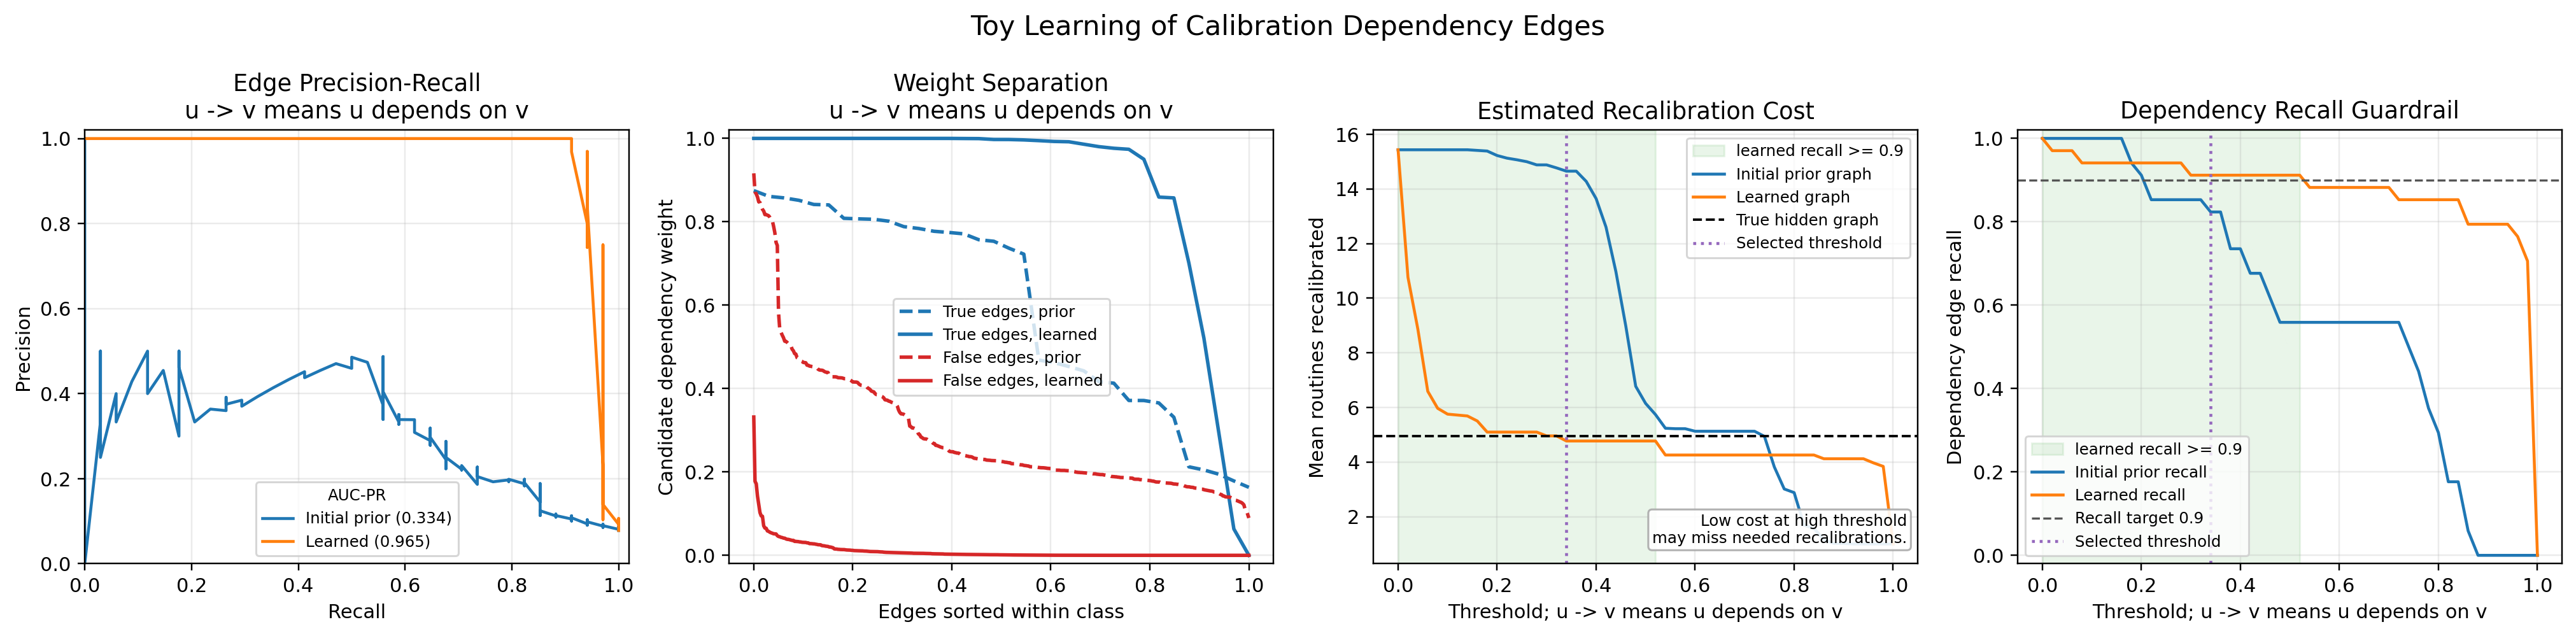

In [ ]:
plot_pr_curves(labels, initial_weights, learned_weights, OUTPUT_DIR / "edge_precision_recall_curve.png")
plot_weight_heatmaps(
    config.n_nodes,
    edges,
    true_edges,
    initial_weights,
    learned_weights,
    OUTPUT_DIR / "edge_weight_heatmap_before_after.png",
)
plot_cost_curve(
    thresholds,
    prior_costs,
    learned_costs,
    true_cost,
    np.array(learned_tradeoff["edge_recall"], dtype=float),
    float(selected["selected_threshold"]),
    OUTPUT_DIR / "cost_recall_tradeoff.png",
)
plot_proposal_summary_figure(
    labels,
    initial_weights,
    learned_weights,
    thresholds,
    prior_costs,
    learned_costs,
    true_cost,
    np.array(prior_tradeoff["edge_recall"], dtype=float),
    np.array(learned_tradeoff["edge_recall"], dtype=float),
    float(selected["selected_threshold"]),
    OUTPUT_DIR / "proposal_summary_figure.png",
)

metrics = {
    "initial_auc_pr": initial_metrics["auc_pr"],
    "learned_auc_pr": learned_metrics["auc_pr"],
    "initial_best_f1": initial_metrics["best_f1"],
    "learned_best_f1": learned_metrics["best_f1"],
    "cost_prior_at_threshold_0_5": cost_prior_05,
    "cost_learned_at_threshold_0_5": cost_learned_05,
    "cost_true": true_cost,
    "selected_threshold": selected["selected_threshold"],
    "selected_threshold_metrics": selected,
    "threshold_curves": {
        "initial_prior": prior_tradeoff,
        "learned": learned_tradeoff,
    },
    "config": config_for_json(config),
}
with (OUTPUT_DIR / "metrics.json").open("w", encoding="utf-8") as handle:
    json.dump(metrics, handle, indent=2)
    handle.write("\n")

display(Image(filename=str(OUTPUT_DIR / "proposal_summary_figure.png")))

## Interpretation

In this controlled toy setting, the learned weights separate hidden true dependencies from false candidates more cleanly than the initial prior. The selected threshold preserves high dependency-edge recall while reducing the estimated recalibration cost relative to the dense prior. This means the learner is not only assigning larger weights to true dependencies, but is also finding an operating point where pruning low-weight edges does not delete many true downstream recalibration relationships.

The cost and recall panels should be read together. Recalibration cost usually falls as the threshold rises because fewer edges remain in the graph, but that improvement is useful only while recall stays high. Once recall drops, the apparent cost reduction can mean the graph is missing real dependencies and would fail to trigger some needed recalibrations after a drift.


## Limitations

- Observations are synthetic, not hardware measurements.
- Drift propagation is a simple probabilistic graph process.
- There is no real pulse/control data and no Optimus integration.
- The update rule is heuristic rather than physically derived.
- The method may require a relatively high overhead of data collection when initially determining which dependencies should exist.

## Reproduce

Run the notebook top to bottom, or run:

```bash
python simulate_dependency_learning.py --output-dir outputs
```

The key artifacts are `outputs/proposal_summary_figure.png`, `outputs/edge_precision_recall_curve.png`, `outputs/cost_recall_tradeoff.png`, and `outputs/metrics.json`.